# DRO-Inspired Optimization under Location-Based OOD Evaluation

## Purpose

This notebook evaluates a DRO-inspired optimization strategy under the location-based OOD framework.

The objective is to assess whether emphasizing higher-risk environments during training improves robustness when models are evaluated on previously unseen disaster locations.

## Motivation

Optimization-level robustness approaches attempt to improve generalization by reducing the influence of easy environments and increasing attention to environments where empirical risk is higher.

In disaster damage assessment, some disaster locations may present substantially greater difficulty than others due to differences in damage patterns, building characteristics, or environmental conditions.

## Main Tasks

* Execute the DRO-inspired model
* Evaluate performance on OOD partitions
* Analyze worst-environment performance
* Aggregate results across random seeds
* Compute confidence intervals
* Generate confusion matrices

## Inputs

```text
OOD_train
OOD_test
OOD_hold
```

generated during OOD preprocessing.

## Outputs

The notebook generates:

* Average OOD Macro F1
* Worst-location performance metrics
* Class-specific OOD F1 scores
* Confidence intervals
* Confusion matrices
* Robustness summary statistics

These outputs are used to evaluate the effectiveness of optimization-level robustness under location-based distribution shift.


## Load packages

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


## Run the model

In [1]:
import sys
!{sys.executable} model/OOD_dro_classifier.py

Loading OOD data...

Using environment column for DRO groups: disaster

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

OOD validation label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

OOD hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Train environments:
['hurricane-harvey', 'hurricane-matthew', 'mexico-earthquake', 'palu-tsunami']

OOD validation environments:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

OOD hold environments:
['hurricane-michael', 'socal-fire']

Image overlap check:
OOD_train intersection OOD_val: 0
OOD_train in

Dro addition: worst environment

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

root = Path(
    "/Users/paolo/Desktop/OOD_training_outputs/"
    "baseline_resnet50_dro_unweighted_5seeds_1se"
)

csv_files = sorted(root.glob("seed_*/ood_hold_predictions_selected_1se.csv"))

all_results = []

for file in csv_files:
    seed = int(file.parent.name.replace("seed_", ""))
    df = pd.read_csv(file)

    for env in sorted(df["disaster"].dropna().unique()):
        env_df = df[df["disaster"] == env]

        macro_f1 = f1_score(
            env_df["target_id"],
            env_df["pred_id"],
            average="macro",
            labels=[0, 1, 2, 3],
            zero_division=0
        )

        all_results.append({
            "seed": seed,
            "environment": env,
            "macro_f1": macro_f1
        })

results_df = pd.DataFrame(all_results)

summary = (
    results_df
    .groupby("environment")["macro_f1"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .sort_values("mean")
)

summary["se"] = summary["std"] / (summary["count"] ** 0.5)

print("\nDRO OOD HOLD environment summary:")
print(summary.round(4).to_string(index=False))

worst = summary.iloc[0]

print("\nWorst DRO OOD HOLD environment:")
print({
    "environment": worst["environment"],
    "macro_f1_mean": round(float(worst["mean"]), 4),
    "macro_f1_std": round(float(worst["std"]), 4),
    "macro_f1_min": round(float(worst["min"]), 4),
    "macro_f1_max": round(float(worst["max"]), 4),
    "num_seeds": int(worst["count"]),
    "macro_f1_se": round(float(worst["se"]), 4)
})


DRO OOD HOLD environment summary:
      environment   mean    std    min    max  count     se
       socal-fire 0.2751 0.0224 0.2413 0.2968      5 0.0100
hurricane-michael 0.3482 0.0194 0.3203 0.3675      5 0.0087

Worst DRO OOD HOLD environment:
{'environment': 'socal-fire', 'macro_f1_mean': 0.2751, 'macro_f1_std': 0.0224, 'macro_f1_min': 0.2413, 'macro_f1_max': 0.2968, 'num_seeds': 5, 'macro_f1_se': 0.01}


## Check confidence intervals

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import t

# ============================================================
# Configuration
# ============================================================

BASE_DIR = Path.home() / "Desktop"

RESULTS_DIR = BASE_DIR / "OOD_training_outputs" / "baseline_resnet50_dro_unweighted_5seeds_1se"

FINAL_RESULTS_PATH = RESULTS_DIR / "final_results_by_seed_selected_1se.csv"
PER_CLASS_PATH = RESULTS_DIR / "all_seed_per_class_metrics_selected_1se.csv"
PER_ENV_PATH = RESULTS_DIR / "all_seed_per_environment_metrics_selected_1se.csv"

OUTPUT_DIR = RESULTS_DIR / "confidence_intervals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIDENCE_LEVEL = 0.95


# ============================================================
# Helper function
# ============================================================

def compute_t_confidence_interval(values, confidence_level=0.95):
    values = pd.Series(values).dropna().astype(float)
    n = len(values)

    if n < 2:
        return {
            "n": n,
            "mean": float(values.mean()) if n == 1 else np.nan,
            "std": np.nan,
            "se": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "margin": np.nan,
        }

    mean = values.mean()
    std = values.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence_level
    t_value = t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_value * se

    return {
        "n": int(n),
        "mean": float(mean),
        "std": float(std),
        "se": float(se),
        "ci_lower": float(mean - margin),
        "ci_upper": float(mean + margin),
        "margin": float(margin),
    }


def summarize_metrics(df, metric_columns, confidence_level=0.95):
    rows = []

    for metric in metric_columns:
        if metric not in df.columns:
            print(f"Skipping missing metric: {metric}")
            continue

        stats = compute_t_confidence_interval(
            df[metric],
            confidence_level=confidence_level,
        )

        rows.append({
            "metric": metric,
            **stats,
        })

    return pd.DataFrame(rows)


# ============================================================
# 1. Model-level confidence intervals
# ============================================================

final_df = pd.read_csv(FINAL_RESULTS_PATH)

model_metric_columns = [
    "ood_val_macro_f1",
    "ood_hold_macro_f1",
    "ood_val_loss",
    "ood_hold_loss",
    "ood_val_f1_no_damage",
    "ood_val_f1_minor",
    "ood_val_f1_major",
    "ood_val_f1_destroyed",
    "ood_hold_f1_no_damage",
    "ood_hold_f1_minor",
    "ood_hold_f1_major",
    "ood_hold_f1_destroyed",
]

model_ci = summarize_metrics(
    final_df,
    model_metric_columns,
    confidence_level=CONFIDENCE_LEVEL,
)

model_ci.to_csv(
    OUTPUT_DIR / "model_level_95_confidence_intervals.csv",
    index=False,
)

print("\nModel-level 95% confidence intervals:")
display(model_ci.round(4))


# ============================================================
# 2. Per-class confidence intervals
# ============================================================

if PER_CLASS_PATH.exists():
    per_class_df = pd.read_csv(PER_CLASS_PATH)

    per_class_rows = []

    for (split, class_id, class_name), group in per_class_df.groupby(
        ["split", "class_id", "class_name"]
    ):
        stats = compute_t_confidence_interval(
            group["f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_class_rows.append({
            "split": split,
            "class_id": class_id,
            "class_name": class_name,
            "metric": "f1",
            **stats,
        })

    per_class_ci = pd.DataFrame(per_class_rows)

    per_class_ci.to_csv(
        OUTPUT_DIR / "per_class_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-class 95% confidence intervals:")
    display(per_class_ci.round(4))

else:
    print(f"\nPer-class file not found: {PER_CLASS_PATH}")


# ============================================================
# 3. Per-environment confidence intervals
# ============================================================

if PER_ENV_PATH.exists():
    per_env_df = pd.read_csv(PER_ENV_PATH)

    per_env_rows = []

    for (split, environment), group in per_env_df.groupby(
        ["split", "environment"]
    ):
        stats = compute_t_confidence_interval(
            group["macro_f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_env_rows.append({
            "split": split,
            "environment": environment,
            "metric": "macro_f1",
            **stats,
        })

    per_env_ci = pd.DataFrame(per_env_rows)

    per_env_ci.to_csv(
        OUTPUT_DIR / "per_environment_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-environment 95% confidence intervals:")
    display(per_env_ci.round(4))

else:
    print(f"\nPer-environment file not found: {PER_ENV_PATH}")



print("\nSaved confidence interval outputs to:")
print(OUTPUT_DIR)


Model-level 95% confidence intervals:


,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_val_macro_f1,5,0.4245,0.0353,0.0158,0.3807,0.4684,0.0439
1,ood_hold_macro_f1,5,0.3411,0.0218,0.0098,0.3140,0.3682,0.0271
2,ood_val_loss,5,1.0094,0.0705,0.0315,0.9219,1.0969,0.0875
3,ood_hold_loss,5,1.0566,0.0161,0.0072,1.0367,1.0766,0.0199
4,ood_val_f1_no_damage,5,0.7695,0.0421,0.0188,0.7173,0.8218,0.0523
5,ood_val_f1_minor,5,0.0385,0.0049,0.0022,0.0324,0.0445,0.0060
6,ood_val_f1_major,5,0.1563,0.0197,0.0088,0.1318,0.1808,0.0245
7,ood_val_f1_destroyed,5,0.7338,0.1005,0.0450,0.6090,0.8587,0.1248
8,ood_hold_f1_no_damage,5,0.7870,0.0131,0.0059,0.7706,0.8033,0.0163
9,ood_hold_f1_minor,5,0.2836,0.0425,0.0190,0.2308,0.3364,0.0528



Per-class 95% confidence intervals:


,split,class_id,class_name,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_hold,0,no-damage,f1,5,0.7870,0.0131,0.0059,0.7706,0.8033,0.0163
1,ood_hold,1,minor-damage,f1,5,0.2836,0.0425,0.0190,0.2308,0.3364,0.0528
2,ood_hold,2,major-damage,f1,5,0.1060,0.0287,0.0128,0.0704,0.1416,0.0356
3,ood_hold,3,destroyed,f1,5,0.1879,0.0645,0.0289,0.1078,0.2680,0.0801



Per-environment 95% confidence intervals:


,split,environment,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_hold,hurricane-michael,macro_f1,5,0.3482,0.0194,0.0087,0.3241,0.3723,0.0241
1,ood_hold,socal-fire,macro_f1,5,0.2751,0.0224,0.0100,0.2473,0.3029,0.0278



Saved confidence interval outputs to:
/Users/paolo/Desktop/OOD_training_outputs/baseline_resnet50_dro_unweighted_5seeds_1se/confidence_intervals


## Confusion matrix

Loaded rows: 267015
Seeds loaded: [42, 123, 999, 2024, 2025]
Rows per seed:
seed
42      53403
123     53403
999     53403
2024    53403
2025    53403
Name: count, dtype: int64

Pooled normalized confusion matrix:
              no-damage  minor-damage  major-damage  destroyed
no-damage         0.768         0.178         0.044      0.011
minor-damage      0.560         0.357         0.059      0.024
major-damage      0.455         0.376         0.107      0.062
destroyed         0.264         0.451         0.155      0.130


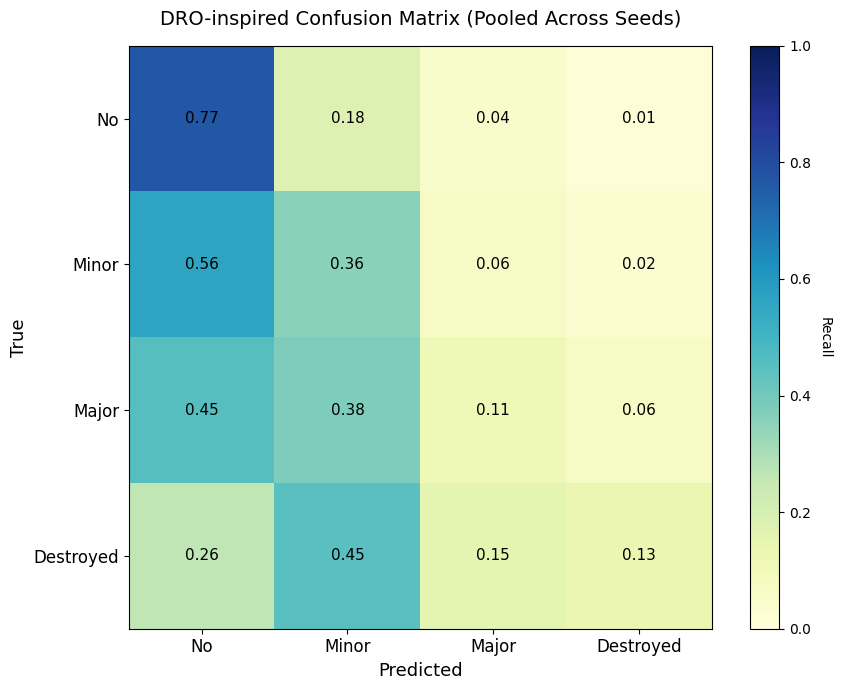

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:
    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed
    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(df))
print("Seeds loaded:", sorted(df["seed"].unique()))
print("Rows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:")
print(pd.DataFrame(cm_norm, index=labels, columns=labels).round(3))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Recall", rotation=270, labelpad=15)

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(short_labels, fontsize=12)
ax.set_yticklabels(short_labels, fontsize=12)

ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)

ax.set_title(
    "DRO-inspired Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

plt.tight_layout()
plt.show()

## Hurricanes comparison

### Hurricane Michael

In [10]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-michael"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

# ============================================================
# Load all seeds
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

# ============================================================
# Filter disaster
# ============================================================

subset = df[df["disaster"] == DISASTER_NAME].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
)

print(f"\nMacro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")

print(cm)


Loaded rows: 267015

Samples in hurricane-michael: 175635

Macro F1 (hurricane-michael): 0.3506

Classification Report:

              precision    recall  f1-score   support

           0     0.7249    0.7257    0.7253    113455
           1     0.3150    0.3591    0.3356     41460
           2     0.1514    0.1046    0.1237     14595
           3     0.2510    0.1925    0.2179      6125

    accuracy                         0.5690    175635
   macro avg     0.3606    0.3455    0.3506    175635
weighted avg     0.5639    0.5690    0.5656    175635


Normalized Confusion Matrix:

[[0.72573267 0.21342382 0.04684677 0.01399674]
 [0.55779064 0.35906898 0.05890014 0.02424023]
 [0.46118534 0.37074341 0.10462487 0.06344639]
 [0.22808163 0.44881633 0.13061224 0.1924898 ]]


### Hurricane Florence

In [12]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-florence"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

# ============================================================
# Load OOD validation predictions across all seeds
# Florence is in OOD_test -> validation predictions
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_val_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed

    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nAvailable disaster names:")
print(sorted(df["disaster"].astype(str).unique()))

# ============================================================
# Filter Florence
# ============================================================

subset = df[
    df["disaster"]
    .astype(str)
    .str.strip()
    .str.lower()
    == DISASTER_NAME.lower()
].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

if len(subset) == 0:
    raise ValueError(
        f"No samples found for disaster: {DISASTER_NAME}"
    )

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
    labels=[0, 1, 2, 3],
    zero_division=0,
)

print(f"\nPooled Macro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Normalized confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    labels=[0, 1, 2, 3],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")
print(cm)

# ============================================================
# Pretty DataFrame version
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion Matrix DataFrame:\n")
print(cm_df.round(3))


Loaded rows: 234165

Seeds loaded:
[42, 123, 999, 2024, 2025]

Available disaster names:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

Samples in hurricane-florence: 53640

Pooled Macro F1 (hurricane-florence): 0.2909

Classification Report:

              precision    recall  f1-score   support

   no-damage     0.8671    0.6176    0.7214     42330
minor-damage     0.0263    0.1845    0.0460      1160
major-damage     0.3109    0.4563    0.3698      9745
   destroyed     0.0181    0.0469    0.0262       405

    accuracy                         0.5746     53640
   macro avg     0.3056    0.3263    0.2909     53640
weighted avg     0.7415    0.5746    0.6377     53640


Normalized Confusion Matrix:

[[0.61762343 0.14349161 0.21974959 0.01913536]
 [0.47241379 0.18448276 0.32844828 0.01465517]
 [0.34273987 0.18019497 0.45633658 0.02072858]
 [0.29135802 0.2345679  0.42716049 0.04691358]]

Confusion Matrix DataFrame:

              no-damage  mino

## Actual vs Predicted

Available splits:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected split: 53403
Rows in prediction file: 53403

Number of available images: 1191

First available image IDs:
image_id
hurricane-michael_00000470    261
socal-fire_00000806           243
hurricane-michael_00000513    236
socal-fire_00000902           232
hurricane-michael_00000527    230
Name: count, dtype: int64

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


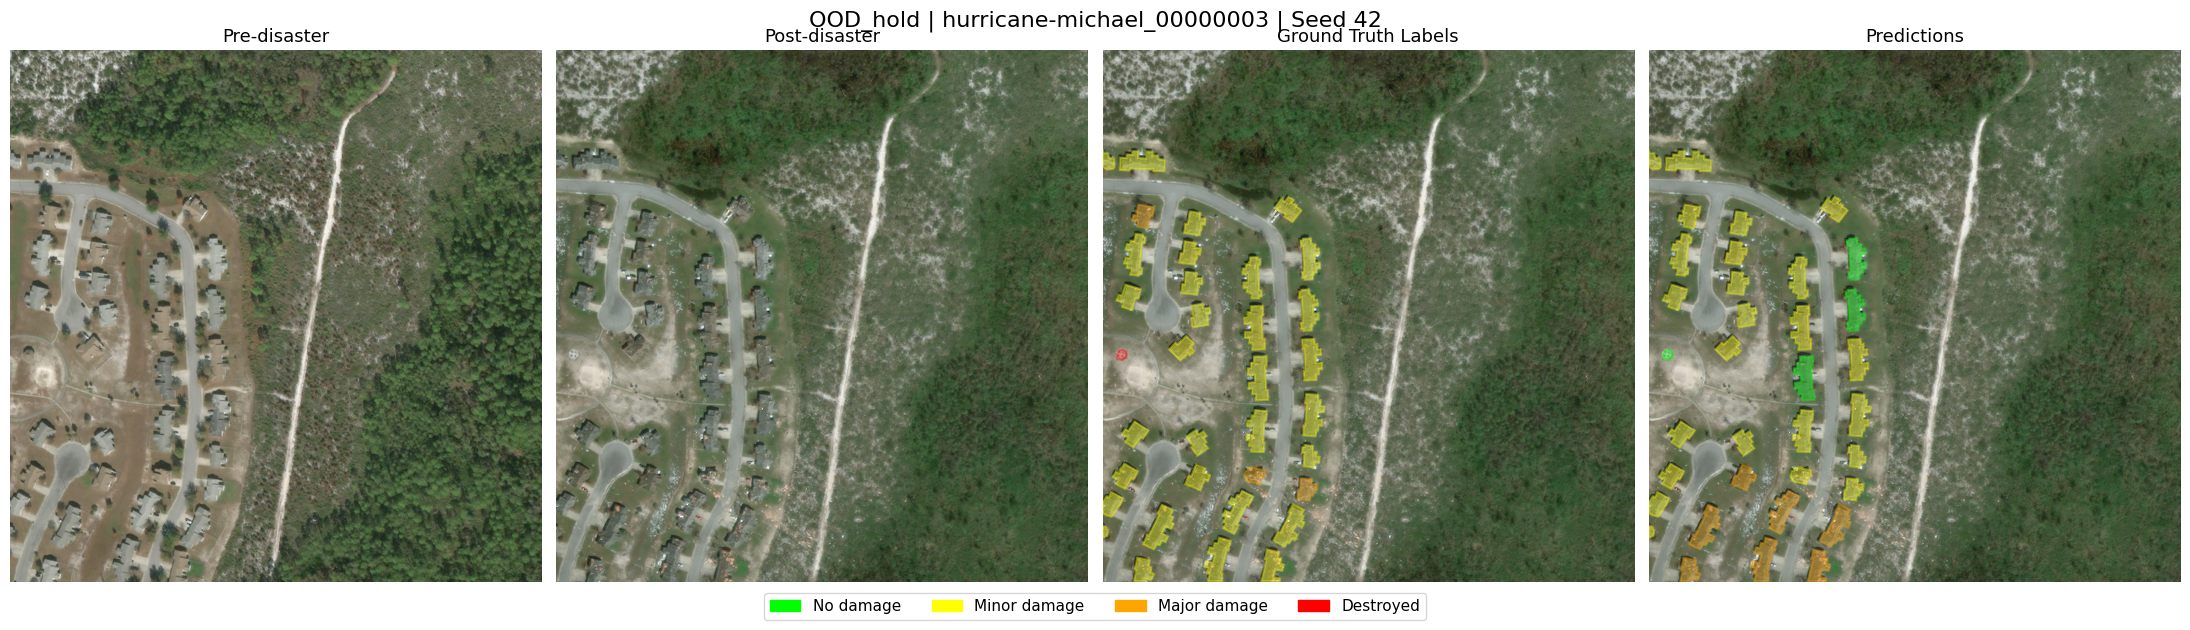

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "OOD_hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "OOD_processed"
    / "buildings_all_OOD_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "baseline_resnet50_dro_unweighted_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "ood_hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 520

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()